# Week 10

### K-Means Clustering (Elbow Method, Silhouette Score, Feature Scaling, Distance Metrics)

In [43]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

### Austin dataset

Austin k=1, SSE=546156.00
Austin k=2, SSE=503559.02
Austin k=3, SSE=470393.50
Austin k=4, SSE=453231.06
Austin k=5, SSE=431096.85
Austin k=6, SSE=408893.84
Austin k=7, SSE=390493.32
Austin k=8, SSE=376135.77
Austin k=9, SSE=363204.45
Austin k=10, SSE=353098.65
Austin k=11, SSE=338891.36
Austin k=12, SSE=322426.46


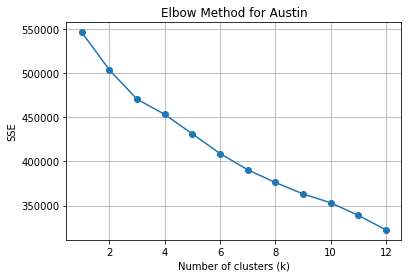

Austin k=2, Silhouette Score=0.1185
Austin k=3, Silhouette Score=0.1187
Austin k=4, Silhouette Score=0.0844
Austin k=5, Silhouette Score=0.0974
Austin k=6, Silhouette Score=0.1031
Austin k=7, Silhouette Score=0.0906
Austin k=8, Silhouette Score=0.1150
Austin k=9, Silhouette Score=0.1029
Austin k=10, Silhouette Score=0.1006
Austin k=11, Silhouette Score=0.1301
Austin k=12, Silhouette Score=0.1025


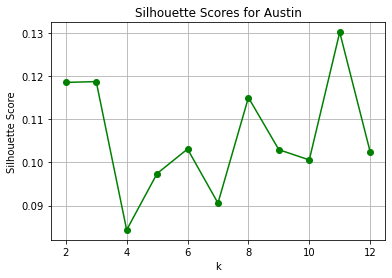

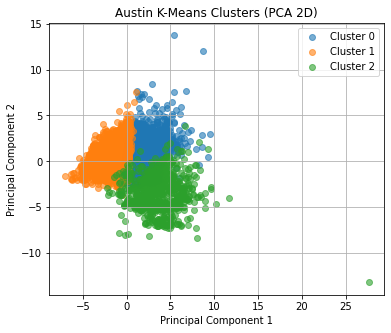

In [44]:
# Load Austin data
austin_df = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/cleaned_austin_data.csv")

# Prepare for clustering
def prepare_for_clustering(df, drop_cols=[]):
    df = df.drop(columns=drop_cols, errors='ignore').dropna()
    numeric_df = df.select_dtypes(include=[np.number])
    scaler = StandardScaler()
    scaled = scaler.fit_transform(numeric_df)
    return scaled, numeric_df

austin_data_scaled, austin_numeric = prepare_for_clustering(
    austin_df,
    drop_cols=['city', 'latest_saledate', 'high_price', 'latestPrice']
)

# Elbow plot
def plot_elbow(data, max_k=12, dataset_name="Dataset"):
    sse = []
    for k in range(1, max_k+1):
        km = KMeans(n_clusters=k, random_state=42)
        km.fit(data)
        sse.append(km.inertia_)
        print(f"{dataset_name} k={k}, SSE={km.inertia_:.2f}")
    plt.figure(figsize=(6,4))
    plt.plot(range(1, max_k+1), sse, marker='o')
    plt.title(f'Elbow Method for {dataset_name}')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('SSE')
    plt.grid(True)
    plt.show()

# Silhouette plot
def plot_silhouette(data, max_k=12, dataset_name="Dataset"):
    scores = []
    for k in range(2, max_k+1):
        km = KMeans(n_clusters=k, random_state=42)
        labels = km.fit_predict(data)
        score = silhouette_score(data, labels)
        scores.append(score)
        print(f"{dataset_name} k={k}, Silhouette Score={score:.4f}")
    plt.figure(figsize=(6,4))
    plt.plot(range(2, max_k+1), scores, marker='o', color='green')
    plt.title(f'Silhouette Scores for {dataset_name}')
    plt.xlabel('k')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()

# Run elbow and silhouette
plot_elbow(austin_data_scaled, dataset_name="Austin")
plot_silhouette(austin_data_scaled, dataset_name="Austin")

# Fit final model and visualize
k = 3  # You can change this based on elbow/silhouette
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(austin_data_scaled)

# Use PCA for 2D visualization
pca = PCA(n_components=2)
reduced = pca.fit_transform(austin_data_scaled)

plt.figure(figsize=(6,5))
for cluster in range(k):
    plt.scatter(reduced[labels == cluster, 0], reduced[labels == cluster, 1], label=f'Cluster {cluster}', alpha=0.6)
plt.title('Austin K-Means Clusters (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

**Austin Dataset Interpretation**

The elbow method for the Austin dataset shows a steady decline in Sum of Squared Errors (SSE) as the number of clusters (k) increases from 1 to 12. There is no clear “elbow” point where the SSE drops sharply and then levels off. However, the rate of decline begins to slow around k = 3 to 5, which may suggest an appropriate cluster range. The absence of a pronounced elbow makes it difficult to select the optimal number of clusters solely from the SSE perspective.

The silhouette scores for the Austin dataset are consistently low, with values ranging from approximately 0.08 to 0.13. The highest silhouette score occurs at k = 11 (0.1301), followed by k = 3 (0.1187) and k = 8 (0.1150). These scores indicate that the cluster separation is not particularly strong, and that the clusters formed may be overlapping or not well-defined. Low silhouette values can occur when clusters are not clearly distinguishable in feature space or if the data contains noise and variability that affects clustering performance.

The 2D PCA visualization with k = 3 provides a visual sense of the clustering result. Three distinct clusters are present, although there is visible overlap among them. This visual evidence aligns with the low silhouette scores and suggests that while some separation exists, the clusters are not well-separated.

Overall, the clustering results for the Austin dataset are not particularly strong. The best candidate for k appears to be 3 based on both the visualization and one of the top silhouette scores. However, the low silhouette values and the lack of a distinct elbow indicate that K-Means may not be the ideal algorithm for this dataset. The features used may not form distinct spherical clusters, which K-Means tends to favor. Exploring alternative clustering methods such as DBSCAN or Gaussian Mixture Models could potentially yield better results.

### Airbnb dataset

Airbnb k=1, SSE=494547.00
Airbnb k=2, SSE=463775.57
Airbnb k=3, SSE=439430.45
Airbnb k=4, SSE=418194.42
Airbnb k=5, SSE=394985.22
Airbnb k=6, SSE=374792.47
Airbnb k=7, SSE=356033.07
Airbnb k=8, SSE=344761.37
Airbnb k=9, SSE=329962.33
Airbnb k=10, SSE=314677.03
Airbnb k=11, SSE=308102.12
Airbnb k=12, SSE=295628.33


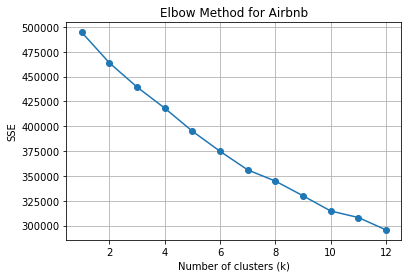

Airbnb k=2, Silhouette Score=0.5786
Airbnb k=3, Silhouette Score=0.0679
Airbnb k=4, Silhouette Score=0.0506
Airbnb k=5, Silhouette Score=0.0830
Airbnb k=6, Silhouette Score=0.0773
Airbnb k=7, Silhouette Score=0.0805
Airbnb k=8, Silhouette Score=0.0793
Airbnb k=9, Silhouette Score=0.0881
Airbnb k=10, Silhouette Score=0.0742
Airbnb k=11, Silhouette Score=0.0780
Airbnb k=12, Silhouette Score=0.0824


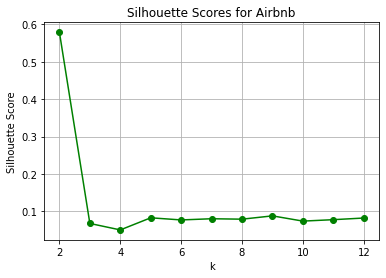

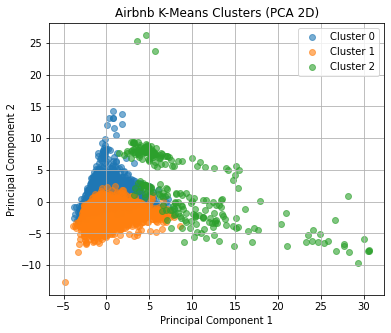

In [45]:
# Load Airbnb data
airbnb_df = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/listings_cleaned.csv")

# Prepare Airbnb data
airbnb_drop_cols = airbnb_df.select_dtypes(include=['object']).columns.tolist() + ['id', 'price', 'high_price']
airbnb_data_scaled, airbnb_numeric = prepare_for_clustering(airbnb_df, drop_cols=airbnb_drop_cols)

# Elbow and silhouette plots
plot_elbow(airbnb_data_scaled, dataset_name="Airbnb")
plot_silhouette(airbnb_data_scaled, dataset_name="Airbnb")

# Fit final model and visualize
k = 3  # Adjust if needed
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(airbnb_data_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2)
reduced = pca.fit_transform(airbnb_data_scaled)

plt.figure(figsize=(6,5))
for cluster in range(k):
    plt.scatter(reduced[labels == cluster, 0], reduced[labels == cluster, 1], label=f'Cluster {cluster}', alpha=0.6)
plt.title('Airbnb K-Means Clusters (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

**Airbnb Dataset Interpretation**

For the Airbnb dataset, the elbow method reveals a consistent decline in SSE as the number of clusters increases from 1 to 12. The most significant reduction in SSE occurs between k = 1 and k = 3, after which the gains diminish. This suggests that the majority of variance is captured by the first few clusters and that additional clusters yield only marginal improvements in compactness.

Silhouette analysis provides clearer guidance in this case. The silhouette score for k = 2 is exceptionally high at 0.5786, which indicates that the clusters are well-separated and internally cohesive. All other k values from 3 to 12 show much lower silhouette scores, generally under 0.1. This dramatic drop indicates that beyond two clusters, the separation between groups becomes much weaker and less meaningful. The sharp contrast between k = 2 and the rest suggests that two is the most appropriate number of clusters for the Airbnb data.

The PCA visualization for k = 3 shows three clusters with some separation, though one of the clusters appears to be more dispersed and overlaps with the others. This aligns with the silhouette results and indicates that moving beyond two clusters may introduce less meaningful divisions.

In summary, the Airbnb dataset shows stronger clustering results than the Austin dataset. The best choice of k is clearly 2, supported by both the silhouette score and the elbow plot. The high silhouette score at k = 2 suggests that the Airbnb listings form two distinct groups in the feature space, which could potentially reflect meaningful differences such as host behavior, property type, or neighborhood characteristics. Additional analysis would be helpful to understand what these two clusters represent.

# Week 11

### DBSCAN & Hierarchical Agglomerative Clustering with Dendrograms


In [46]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# Function to apply DBSCAN with eps tuning using k-distance graph
def tune_dbscan(data, dataset_name="Dataset", min_samples=5):
    # Plot k-distance graph to help choose eps
    neigh = NearestNeighbors(n_neighbors=min_samples)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)
    k_distances = sorted(distances[:, -1])
    
    plt.figure(figsize=(6, 4))
    plt.plot(k_distances)
    plt.title(f'k-distance Graph for {dataset_name}')
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'{min_samples}th Nearest Neighbor Distance')
    plt.grid(True)
    plt.show()

# Function to apply DBSCAN and report results
def run_dbscan(data, dataset_name="Dataset", eps=0.8, min_samples=5):
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(data)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        score = silhouette_score(data, labels)
    else:
        score = -1
    print(f"--- DBSCAN ({dataset_name}) ---")
    print(f"DBSCAN clusters (excluding noise): {n_clusters}")
    print(f"DBSCAN Silhouette Score: {score:.4f}")
    
    # PCA visualization
    reduced = PCA(n_components=2).fit_transform(data)
    plt.figure(figsize=(6, 5))
    plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='viridis', s=10)
    plt.title(f'{dataset_name} - DBSCAN Clusters (PCA 2D)')
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

# Function to apply Hierarchical Agglomerative Clustering
def run_hac(data, dataset_name="Dataset", n_clusters=3):
    hac = AgglomerativeClustering(n_clusters=n_clusters)
    labels = hac.fit_predict(data)
    score = silhouette_score(data, labels)
    print(f"--- Hierarchical Agglomerative Clustering ({dataset_name}) ---")
    print(f"HAC Silhouette Score: {score:.4f}")
    
    # PCA visualization
    reduced = PCA(n_components=2).fit_transform(data)
    plt.figure(figsize=(6, 5))
    plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='tab10', s=10)
    plt.title(f'{dataset_name} - HAC Clusters (PCA 2D)')
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

### Austin dataset

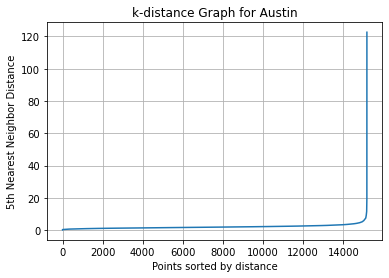

--- DBSCAN (Austin) ---
DBSCAN clusters (excluding noise): 7
DBSCAN Silhouette Score: 0.6164


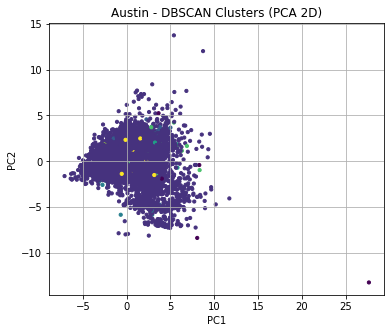

--- Hierarchical Agglomerative Clustering (Austin) ---
HAC Silhouette Score: 0.3563


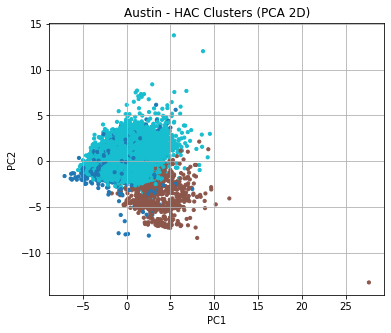

In [47]:
# DBSCAN eps tuning plot 
tune_dbscan(austin_data_scaled, dataset_name="Austin", min_samples=5)

# DBSCAN with tuned eps (adjusting after seeing elbow in k-distance plot)
run_dbscan(austin_data_scaled, dataset_name="Austin", eps=16 , min_samples=5)

# Hierarchical Clustering for Austin
run_hac(austin_data_scaled, dataset_name="Austin", n_clusters=3)

### Airbnb dataset

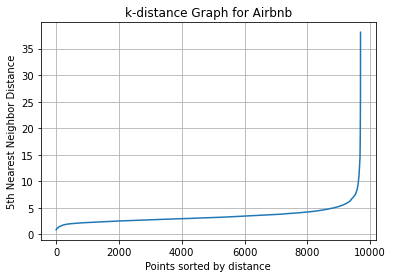

--- DBSCAN (Airbnb) ---
DBSCAN clusters (excluding noise): 7
DBSCAN Silhouette Score: 0.5196


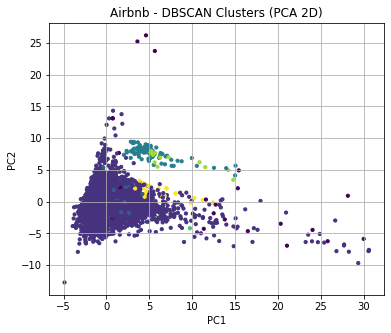

--- Hierarchical Agglomerative Clustering (Airbnb) ---
HAC Silhouette Score: 0.6063


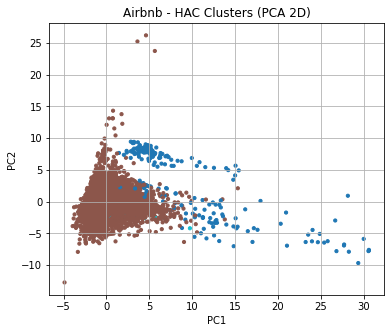

In [48]:
# DBSCAN eps tuning plot (optional)
tune_dbscan(airbnb_data_scaled, dataset_name="Airbnb", min_samples=5)

# DBSCAN with tuned eps (adjust after seeing elbow in k-distance plot)
run_dbscan(airbnb_data_scaled, dataset_name="Airbnb", eps=12, min_samples=5)

# Hierarchical Clustering for Airbnb
run_hac(airbnb_data_scaled, dataset_name="Airbnb", n_clusters=3)

### Fine tuning

In [49]:
def tune_dbscan_range(data, dataset_name="Dataset", eps_values=[0.5, 1.0, 1.5, 2.0], min_samples=5):
    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(data)
    
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(data)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.sum(labels == -1) / len(labels)

        print(f"--- DBSCAN ({dataset_name}) | eps={eps} ---")
        print(f"Clusters (excluding noise): {n_clusters}")
        print(f"Noise points: {np.sum(labels == -1)} ({noise_ratio:.2%})")

        if n_clusters > 1:
            score = silhouette_score(data, labels)
            print(f"Silhouette Score: {score:.4f}")
        else:
            print("Silhouette Score: N/A (too few clusters)")
        
        # Plot PCA 2D Clusters
        plt.figure(figsize=(6, 5))
        plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels, cmap='viridis', s=10)
        plt.title(f'{dataset_name} - DBSCAN (eps={eps})')
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.grid(True)
        plt.show()

--- DBSCAN (Austin) | eps=13 ---
Clusters (excluding noise): 8
Noise points: 8 (0.05%)
Silhouette Score: 0.5838


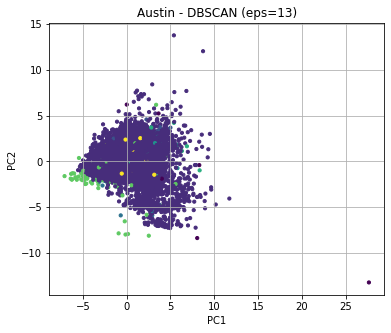

--- DBSCAN (Austin) | eps=14 ---
Clusters (excluding noise): 7
Noise points: 7 (0.05%)
Silhouette Score: 0.6121


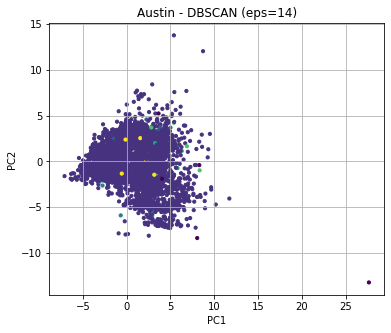

--- DBSCAN (Austin) | eps=15 ---
Clusters (excluding noise): 7
Noise points: 7 (0.05%)
Silhouette Score: 0.6121


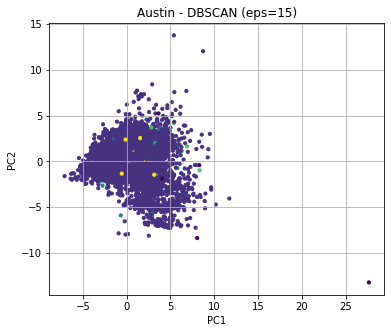

--- DBSCAN (Austin) | eps=16 ---
Clusters (excluding noise): 7
Noise points: 6 (0.04%)
Silhouette Score: 0.6164


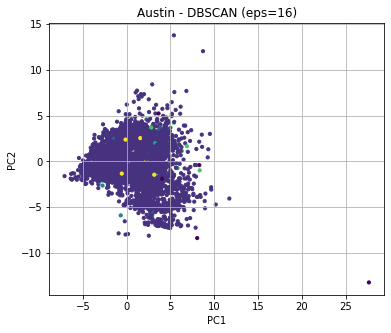

--- DBSCAN (Austin) | eps=17 ---
Clusters (excluding noise): 5
Noise points: 5 (0.03%)
Silhouette Score: 0.7409


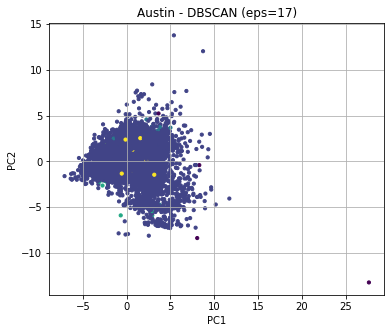

--- DBSCAN (Austin) | eps=18 ---
Clusters (excluding noise): 5
Noise points: 3 (0.02%)
Silhouette Score: 0.7409


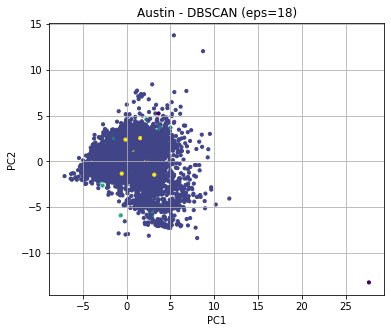

--- DBSCAN (Austin) | eps=19 ---
Clusters (excluding noise): 5
Noise points: 3 (0.02%)
Silhouette Score: 0.7409


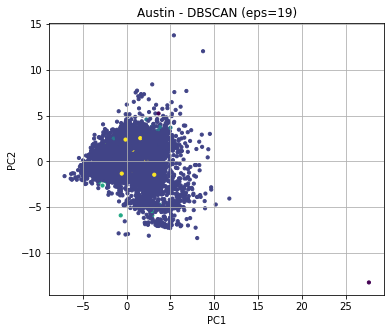

--- DBSCAN (Austin) | eps=20 ---
Clusters (excluding noise): 5
Noise points: 2 (0.01%)
Silhouette Score: 0.7409


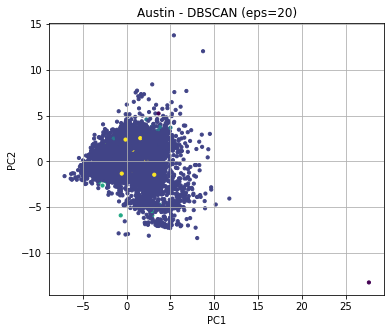

--- DBSCAN (Airbnb) | eps=8.0 ---
Clusters (excluding noise): 12
Noise points: 89 (0.92%)
Silhouette Score: 0.3715


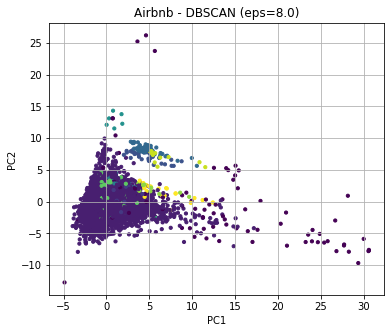

--- DBSCAN (Airbnb) | eps=9.0 ---
Clusters (excluding noise): 12
Noise points: 64 (0.66%)
Silhouette Score: 0.3719


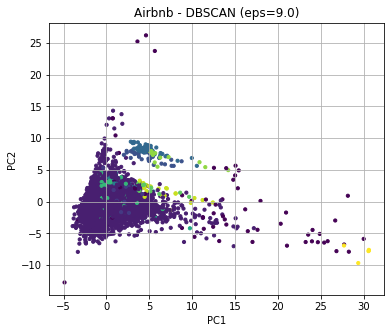

--- DBSCAN (Airbnb) | eps=10 ---
Clusters (excluding noise): 11
Noise points: 43 (0.44%)
Silhouette Score: 0.4330


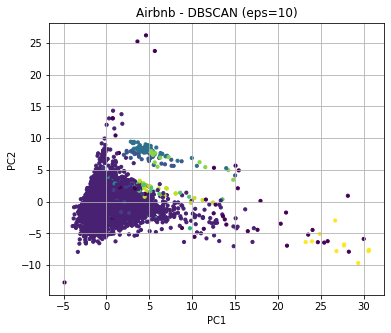

--- DBSCAN (Airbnb) | eps=11 ---
Clusters (excluding noise): 10
Noise points: 33 (0.34%)
Silhouette Score: 0.4332


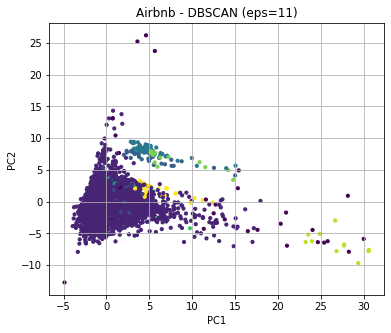

--- DBSCAN (Airbnb) | eps=12 ---
Clusters (excluding noise): 7
Noise points: 25 (0.26%)
Silhouette Score: 0.5196


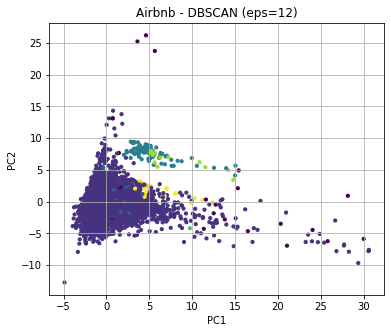

--- DBSCAN (Airbnb) | eps=13 ---
Clusters (excluding noise): 6
Noise points: 18 (0.19%)
Silhouette Score: 0.5133


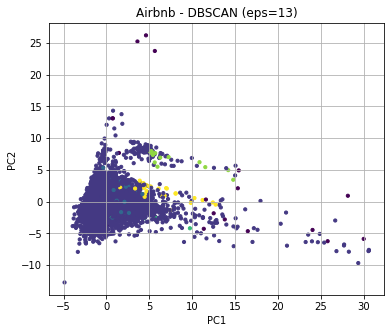

--- DBSCAN (Airbnb) | eps=14 ---
Clusters (excluding noise): 6
Noise points: 15 (0.15%)
Silhouette Score: 0.5132


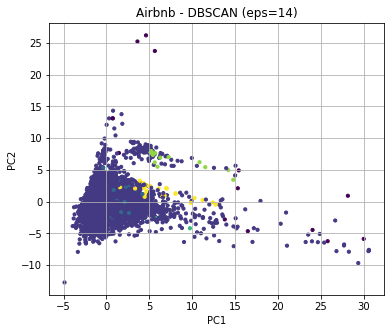

In [50]:
# For Austin
tune_dbscan_range(austin_data_scaled, dataset_name="Austin", eps_values=[13, 14, 15, 16, 17, 18, 19, 20])

# For Airbnb
tune_dbscan_range(airbnb_data_scaled, dataset_name="Airbnb", eps_values=[8.0, 9.0, 10, 11, 12, 13, 14])